# Focal Spot Comparison

This notebook compares the focal spot intensity profiles of an optimized diffractive cascade against a conventional Fresnel zone plate. It loads simulation results from a specific optimization run, reconstructs the simulation grid, and plots the 1D intensity cross-sections at focus for both designs to illustrate the improvement in peak intensity and spot shape achieved by the cascade.

In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import scipy

In [2]:
import sys
from pathlib import Path

repo_root = Path.cwd() if (Path.cwd() / "src").exists() else Path.cwd().parent
sys.path.insert(0, str(repo_root))

from src.forwardmodels import forward_model_N_elements_mask, forward_model_N_elements_mask_2d_coherent_qdht
from src.simparams import SimParams
from src.util import compute_opt_and_fzp_metrics_2d, create_material_map, gaussian_energy_spectrum
from paper.sweeps.density_io import density_half_profile
from paper.sweeps.standard_params import GAP_MAP_DEFAULT, MEMBRANE_MAP_SI3N4, CROP_WIDTH_DEFAULT
from src.inversedesign_utils import zp_init

In [3]:
matplotlib.rcParams['figure.dpi'] = 200
matplotlib.rcParams.update({'font.size': 24})

In [4]:
fzp_color = (np.float64(0.4), np.float64(0.6509803921568628), np.float64(0.11764705882352941), np.float64(1.0))

In [5]:
path = repo_root / "paper_data"

params = np.load(path / "fig1_N_sweeps_params.npy", allow_pickle=True).item()
sweep_arrs = np.load(path / "fig1_N_sweeps_sweep_arrays.npy", allow_pickle=True).item()
results = np.load(path / "fig1_N_sweeps_results_run_0.npz", allow_pickle=True)

materials = sweep_arrs["materials"]
Nelems = sweep_arrs["Nelems"]
material_idx = materials.index("au")
Nelem_idx = int(np.where(Nelems == 10)[0][0])
Nelem = int(Nelems[Nelem_idx])

Nx = int(params["Nx"])
dx = float(params["dx"])

rho_half = density_half_profile(
    results["opt_rhos"],
    (material_idx, Nelem_idx),
    length=Nelem * Nx // 2,
    dtype=np.float64,
)
rho_bar = torch.tensor(rho_half, dtype=torch.float64)
device = torch.device("cpu")

lams, weights = gaussian_energy_spectrum(
    central_energy_ev=float(params["central_energy_ev"]),
    N=int(params["N_wvl"]),
    bandwidth=float(params["bandwidth"]),
    device=device,
    bandwidth_in_wavelength=False,
)

sim_params = SimParams(
    Ny=1,
    Nx=Nx,
    dx=dx,
    device=device,
    dtype=torch.complex128,
    lams=lams,
    weights=weights,
)

Ncenter = int(2 * 1.22 * float(params["min_feature_size"]) / dx)
focusing_mask = torch.zeros(1, Nx, device=device)
focusing_mask[0, Nx // 2 - Ncenter // 2 : Nx // 2 + Ncenter // 2] = 1.0

elem_params = {
    "thickness": float(params["element_thickness"]),
    "elem_map": create_material_map("au"),
    "gap_map": GAP_MAP_DEFAULT,
    "membrane_map": MEMBRANE_MAP_SI3N4,
    "membrane_thickness": float(params["membrane_thickness"]),
    "propagation_method": "angular",
}

z_dists = torch.ones(Nelem - 1, dtype=torch.float64, device=device) * float(params["inter_elem_dist"])
z_dists = torch.cat((z_dists, torch.tensor([float(params["f"])], dtype=torch.float64, device=device)))
fwd_model_args = (elem_params, focusing_mask, z_dists, None)

metrics = compute_opt_and_fzp_metrics_2d(
    rho_bar,
    sim_params,
    fwd_model_args,
    min_feature_size=float(params["min_feature_size"]),
    focusing_threshold=float(params["focusing_threshold"]),
    crop_width=int(CROP_WIDTH_DEFAULT),
    forward_model_1d=forward_model_N_elements_mask,
    forward_model_2d=forward_model_N_elements_mask_2d_coherent_qdht,
    zp_init_func=zp_init,
)

results = {
    "opt_intensity": metrics["opt_intensity_1d"],
    "fzp_intensity": metrics["fzp_intensity_1d"],
    "opt_efficiency": metrics["opt_efficiency"],
    "fzp_efficiency": metrics["fzp_efficiency"],
}

In [6]:
opt_intensity = results['opt_intensity']
fzp_intensity = results["fzp_intensity"]

In [7]:
Nx = params["Nx"]
sim_params = SimParams(
    Ny = 1, 
    Nx = Nx,
    dx = params["dx"],
    device='cpu',
    dtype = torch.complex128,
    lams = [], 
    weights = []
)
x = sim_params.x

In [8]:
opt_efficiency = results["opt_efficiency"]
opt_efficiency

0.3871147468258358

In [9]:
fzp_efficiency = results["fzp_efficiency"]
fzp_efficiency

0.031266357329959596

In [10]:
x_upsample = np.linspace(x.min(), x.max(), int(10*Nx - 1))

opt_cs = scipy.interpolate.CubicSpline(x, opt_intensity)
fzp_cs = scipy.interpolate.CubicSpline(x, fzp_intensity)

opt_intensity_upsample = opt_cs(x_upsample)
fzp_intensity_upsample = fzp_cs(x_upsample)

In [11]:
opt_intensity_upsample.max() / fzp_intensity_upsample.max()

np.float64(7.935588257717232)

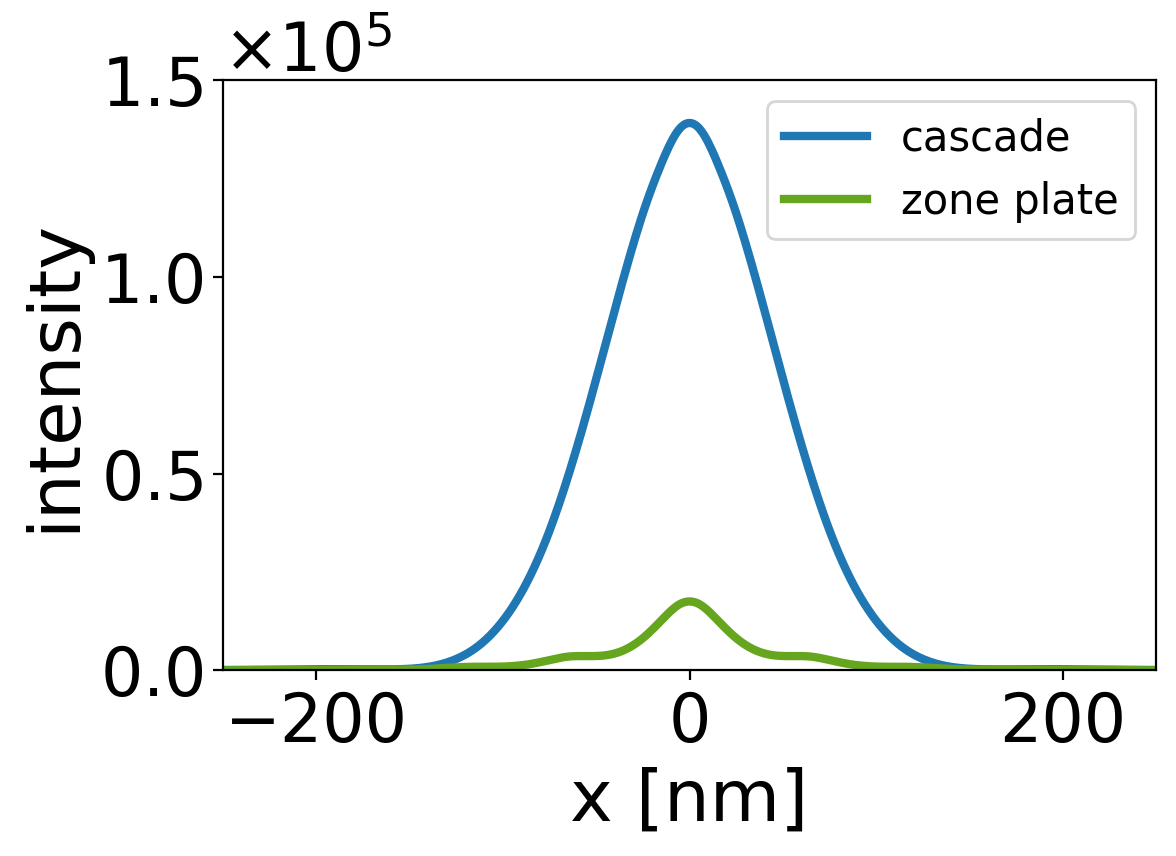

In [12]:
plt.plot(x_upsample*1e9, opt_intensity_upsample, linewidth=3, label='cascade')
plt.plot(x_upsample*1e9, fzp_intensity_upsample, linewidth=3, label='zone plate', color=fzp_color)

plt.xlabel('x [nm]', fontsize=26)
plt.ylabel('intensity', fontsize=26)
plt.xlim(-250, 250)
plt.ylim(0, 1.5e5)
plt.legend(loc='upper right', fontsize=15)
plt.tick_params(labelsize=24)
plt.ticklabel_format(style='sci', axis='y', scilimits=(0,0), useMathText=True) 
plt.tight_layout()
plt.show()